**Descripción del contexto y la procedencia del dataset: qué mide, quién lo recolectó, cuándo, y cuál es la unidad de observación.**
1. Descripción: Datos del artículo *Working memory contributions to reinforcement learning impairments in schizophrenia" (Collins et al., 2014) in JoN (Journal Of Nueroscience)*
2. Acceso: OSF (Open Science Framework)
3. Date Created: Feb 22, 2023, 12:02 PM
4. Date Updated: May 8, 2023, 1:36 PM
5. Contribuidores: CCNLab UC Berkeley (https://ccn.studentorg.berkeley.edu/)
6. Enlace al artículo: https://pubmed.ncbi.nlm.nih.gov/25297101/
7. Cita: Berkeley, C. U. (2023, May 8). Data for Collins et al., 2014 JoN. Retrieved from osf.io/q67tb
8. Enlace para acceso: https://osf.io/q67tb/overview
9.  El repositorio de origen no declara una licencia explícita. Pero se cita a la fuente.
10. Breve resumen del artículo, generado por IA: El paper investiga por qué las personas con esquizofrenia muestran déficits en tareas de aprendizaje por refuerzo, proponiendo que estos no se deben principalmente a fallas en el sistema de reinforcement learning (RL), sino a alteraciones en la working memory (WM). Para ello, los autores utilizan una tarea conductual que manipula la carga de memoria (variando el número de estímulos por bloque) junto con un modelo computacional híbrido (RLWM) que separa ambos procesos. Los resultados muestran que, aunque los pacientes tienen peor desempeño global, sus parámetros de aprendizaje por refuerzo permanecen relativamente intactos; en cambio, presentan menor capacidad de memoria de trabajo, mayor olvido y menor uso de este sistema. Esto sugiere que los déficits observados en aprendizaje no son puramente dopaminérgicos o de RL, sino que emergen principalmente de limitaciones en memoria de trabajo que afectan el desempeño en estas tareas.
11. Datos:
| Columna | Explicación |
|---|---|
| subno | Identificador |
| block | Número de bloque |
| ns | Tamaño de conjunto |
| time | Número de eensayo |
| stimseq | ID del estímulo |
| imageseq | Número de imagen actual |
| folderseq | Número de la categoría de la imagen |
| iterseq | Número de iteración por estímulo |
| corAseq | Acción correcta |
| choice | Acción actual |
| key | Tecla presionada |
| cor | Es correcto? Sí/No -> 0/1 |
| rew | Recibió recompensa? Sí/No -> 0/1 |
| rt | Tiempo de reacción |
| condition (HC=0,SZ=1) | Condición experimental. 0: grupo control / 1: esquizofrenia. **Variable objetivo** |
| pcor | número de ensayos correctos previos para un estímulo dado (utilizado para regresión logística) |
| delay | demora desde el último ensayo correcto para el mismo estímulo |
________________________________________________________________________________

**Verificación de la estructura: dimensiones y tipo de cada atributo, incluyendo una celda inicial que compruebe el cumplimiento de los requisitos anteriores.**

In [10]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy     ", np.__version__)
print("pandas    ", pd.__version__)
print("matplotlib", __import__("matplotlib").__version__)
print("seaborn   ", sns.__version__)

numpy      2.1.3
pandas     2.2.3
matplotlib 3.10.0
seaborn    0.13.2


In [11]:
# crear dataframe
df =pd.read_csv("/content/drive/MyDrive/INTRODUCCIÓN A LA CIENCIA DE DATOS/practicas/practica1/q67tb-osfstorage-archive/CollinsEtAl_2014_JoN.csv")
df

,subno,block,ns,time,stimseq,imageseq,folderseq,iterseq,corAseq,choice,key,cor,rew,rt,"condition (HC=0,SZ=1)",pcor,delay
0,3093,1,6,1,2,1,4,1,2,1,31,0,0,2.807862,1,0,NaN
1,3093,1,6,2,1,4,4,1,1,2,30,0,0,1.069457,1,0,NaN
2,3093,1,6,3,5,3,4,1,3,3,32,1,1,1.028125,1,0,NaN
3,3093,1,6,4,6,2,4,1,3,1,31,0,0,0.889233,1,0,NaN
4,3093,1,6,5,4,5,4,1,2,2,30,1,1,0.808525,1,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46671,82462,13,4,34,1,2,6,8,1,2,32,0,0,0.803903,0,4,4.0
46672,82462,13,4,35,1,2,6,9,1,1,31,1,1,0.421560,0,4,5.0
46673,82462,13,4,36,2,6,6,9,2,2,32,1,1,0.659719,0,6,5.0
46674,82462,13,4,37,3,5,6,10,2,2,32,1,1,0.543558,0,8,5.0


In [12]:
n_filas, n_columnas = df.shape
n_numericas = df.select_dtypes(include="number").shape[1]
n_no_numericas = df.select_dtypes(exclude="number").shape[1]

print(f"Registros:               {n_filas:>5}")
print(f"Atributos:               {n_columnas:>5}")
print(f"  numéricos:             {n_numericas:>5}")
print(f"  no numéricos:          {n_no_numericas:>5}")
print(f"Duplicados exactos:      {df.duplicated().sum():>5}")
print(f"Registros con faltantes: {df.isna().any(axis=1).sum():>5}")

Registros:               46676
Atributos:                  17
  numéricos:                17
  no numéricos:              0
Duplicados exactos:          0
Registros con faltantes: 10544


1. Se marcan 0 datos no numéricos, pero las columnas *'cor'* y *'rew'* son binarias (sí/no), por lo tanto, nominales. Solo que ya vienen procesadas en valores numéricos.
2. No se elimina la columna de ID, ya que hay varios registros para cada participante.

**Análisis de la calidad de los datos: patrón de valores faltantes, duplicados, valores imposibles, y cardinalidad de los atributos categóricos.**

FALTANTES

In [13]:
proporcion_faltantes = df.isna().mean().sort_values(ascending=False)
proporcion_faltantes = proporcion_faltantes[proporcion_faltantes > 0]

pd.DataFrame({
    "faltantes": df.isna().sum()[proporcion_faltantes.index],
    "porcentaje": (proporcion_faltantes * 100).round(1),
})

,faltantes,porcentaje
delay,10544,22.6


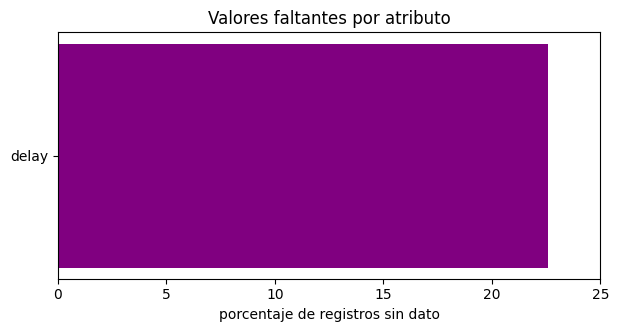

In [14]:
fig, ax = plt.subplots(figsize=(7, 3.2))

ax.barh(proporcion_faltantes.index[::-1],
        proporcion_faltantes.values[::-1] * 100, color="purple")

ax.set_xlabel("porcentaje de registros sin dato")
ax.set_title("Valores faltantes por atributo")
ax.set_xlim(0, 25)
plt.show()

**Lectura.** Solo un atributo tiene faltantes. Que es la demora desde el último ensayo correcto para el mismo estímulo. Por lo que hay que analizar si estos faltantes siguen un patrón.

Verificar si los faltantes en delay son sistemáticos. Ya sea que falta delay por participante, por tamaño de conjunto, por bloque o por estímulo.

In [15]:
columnas = ["subno", "ns", "block", "stimseq"]
faltantes = {}
for columna in columnas:
    faltantes_bloque = (
        df.groupby(columna)["delay"]
        .agg(lotes="size", sin_faltantes=lambda valores: valores.isna().mean())
        .query("lotes >= 30")
        .sort_values("sin_faltantes", ascending=False)
    )
    faltantes[columna] = faltantes_bloque

Primero verificar en tamaño de conjunto, bloque o estímulo. Ya que tienen un número pequeño y se puede visualizar.

In [16]:
print ((faltantes["ns"]["sin_faltantes"] * 100).round(1))
print ((faltantes["block"]["sin_faltantes"] * 100).round(1))
print ((faltantes["stimseq"]["sin_faltantes"] * 100).round(1))

ns
4    23.9
5    23.8
6    22.1
3    22.0
2    20.0
Name: sin_faltantes, dtype: float64
block
1     23.8
3     23.6
2     23.6
12    23.2
8     23.1
11    23.0
9     23.0
13    22.7
6     22.4
10    22.1
7     22.1
4     20.7
5     19.8
Name: sin_faltantes, dtype: float64
stimseq
4    24.3
6    23.8
3    23.4
5    23.1
2    21.8
1    21.4
Name: sin_faltantes, dtype: float64


Luego verificar en participantes. Ya que tienen un número grande y es difícil visualizar, por eso se pide que se muestren aquellos mayores a 30%

In [17]:
faltantes["subno"][faltantes["subno"]["sin_faltantes"] > 0.30]

,lotes,sin_faltantes
subno,,


Los faltantes se distribuyen de maner similar en todas las variables analizadas. Esto sugiere que los faltantes no son sistemáticos. No se encuentra un patrón específico.

DUPLICADOS

In [18]:
print("Duplicados exactos:", df.duplicated().sum())
print("Duplicados en los atributos de unidad experimental:",
      df.duplicated(subset=["ns", "block", "time"]).sum())

Duplicados exactos: 0
Duplicados en los atributos de unidad experimental: 43445


**Lectura.** No hay duplicados exactos. Sí hay muchas filas que comparten los atributos de unidad experimental. Esto es esperado, ya que las tareas experimentales implementadas en el artículo son repetitivas.

VALORES IMPOSIBLES Y FUERA DE RANGO

In [19]:
df.describe().round(1)

,subno,block,ns,time,stimseq,imageseq,folderseq,iterseq,corAseq,choice,key,cor,rew,rt,"condition (HC=0,SZ=1)",pcor,delay
count,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,46676.0,36132.0
mean,60432.6,7.2,4.4,27.2,2.7,3.5,10.6,6.4,2.0,2.0,30.8,0.7,0.7,0.8,0.6,3.4,5.9
std,23476.0,3.6,1.4,20.2,1.5,1.7,5.2,3.8,0.8,0.8,2.1,0.4,0.4,0.4,0.5,3.1,6.2
min,3093.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,1.0
25%,56507.0,4.0,3.0,11.0,1.0,2.0,6.0,3.0,1.0,1.0,30.0,0.0,0.0,0.6,0.0,1.0,2.0
50%,69355.0,8.0,5.0,23.0,2.0,3.0,10.0,6.0,2.0,2.0,31.0,1.0,1.0,0.7,1.0,3.0,4.0
75%,80695.0,10.0,6.0,40.0,4.0,5.0,15.0,9.0,3.0,3.0,32.0,1.0,1.0,1.0,1.0,5.0,8.0
max,82462.0,13.0,6.0,90.0,6.0,6.0,19.0,15.0,3.0,3.0,32.0,1.0,1.0,3.5,1.0,14.0,84.0


Las variables 'choice', 'key', 'cor', 'rew' y 'rt', hasta donde entendí el artículo, no deberían de tener valores negativos.

In [20]:
columnas = ['choice', 'key', 'cor', 'rew', 'rt']
(df[columnas] == -1).sum()

,0
choice,181
key,181
cor,181
rew,181
rt,181


la suma de '-1' para cada columna es el mismo. Lo que sugiere que quizá es una manera de representar datos faltantes.

In [21]:
for columna in columnas:
    print(f"\n--- {columna} ---")
    print(df[columna].unique())


--- choice ---
[ 1  2  3 -1]

--- key ---
[31 30 32 -1]

--- cor ---
[ 0  1 -1]

--- rew ---
[ 0  1 -1]

--- rt ---
[2.80786205 1.06945734 1.02812543 ... 0.65971926 0.54355773 0.72818695]


Aquí se puede observar que sí es un valor predefinido para valores nulos.

CARDINALIDAD Y CODIFICACIÓN INCONSISTENTE

Como se comentó anteriormente, las columnas 'cor' y 'rew' son categoricas (binarias), pero ya estan codificadas en números (1 y 0). Ya revisamos que también tienen datos nulos, marcados como '-1'. Por lo que ya no se hace un análisis más profundo, como de frecuencia de categorías, ya que son variables binarias.

**DESICIONES DE LIMPIEZA.**
1. Los datos, de alguna manera, son series de tiempo. Ya que son secuencias, ensayo a ensayo, de tareas experimentales. Por lo tanto, eliminar los nulos de 'delay' podría afectar. Además, en esa columna un dato nulo no significa que no hubo delay, quizá solo el delay fue tan pequeño que la máquina no lo registró. Por lo tanto, convertir los NaN a 0 es mejor opción.


In [22]:
df["delay"] = df["delay"].fillna(0)
print(df["delay"].isna().sum())

0


2. Los 181 datos marcados con -1 sí son un problema, porque implican falta de respuesta o un mal registro. Por lo tanto, estos sí se eliminan.

In [23]:
df = df[df["choice"] != -1]

In [25]:
columnas = ['choice', 'key', 'cor', 'rew', 'rt']
(df[columnas] == -1).sum()

,0
choice,0
key,0
cor,0
rew,0
rt,0


Antes de continuar con los análisis, hacemos una breve inspección

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46495 entries, 0 to 46675
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subno                  46495 non-null  int64  
 1   block                  46495 non-null  int64  
 2   ns                     46495 non-null  int64  
 3   time                   46495 non-null  int64  
 4   stimseq                46495 non-null  int64  
 5   imageseq               46495 non-null  int64  
 6   folderseq              46495 non-null  int64  
 7   iterseq                46495 non-null  int64  
 8   corAseq                46495 non-null  int64  
 9   choice                 46495 non-null  int64  
 10  key                    46495 non-null  int64  
 11  cor                    46495 non-null  int64  
 12  rew                    46495 non-null  int64  
 13  rt                     46495 non-null  float64
 14  condition (HC=0,SZ=1)  46495 non-null  int64  
 15  pcor   

**ANÁLISIS UNIVARIADO**: distribución y estadísticos descriptivos de los atributos relevantes.


Hasta este paso, solo las columnas 'cor' y 'rew' se habían tomado como categóricas, ya que el que las variables estén codificadas en números permitió una exploración más rápida. Sin embargo, para los siguientes análisis ya conviene realizar una separación entre variables numéricas y categóricas.

Separación de variables en categóricas y numéricas:

| Columna | Escala | Justificación |
|---|---|---|
| subno | Nominal | Los números solo identifican participantes|
| block | Ordinal| Los bloques siguen un orden, pero no representan cantidades |
| ns | Razón | Número de estímulos en el conjunto |
| time | Razón | Secuencia de ensayo |
| stimseq | Nominal | ID del estímulo |
| imageseq | Razón | Secuencia de la imagen. |
| folderseq | Nominal | ID de la categoría de imagen |
| iterseq | Ordinal | Número de iteración por estímulo, un ID |
| corAseq | Nominal | Las acciones son categorías |
| choice | Nominal | Las respuestas son categorías |
| key | Nominal | Tecla presionada. Es una categoría de respuesta, no una magnitud |
| cor | Nominal (dicotómica) | Correcto/incorrecto |
| rew | Nominal (dicotómica) | Recompensa/no recompensa |
| rt | Razón | Tiempo de reacción |
| condition (HC=0,SZ=1) | Nominal (dicotómica) | El 0/1 identifica grupos |
| pcor | Razón | Número de ensayos correctos previos para un estímulo, es un conteo con cero significativo |
| delay | Razón | Demora temporal desde el último ensayo correcto |

In [27]:
variables_numericas = ['ns', 'time', 'imageseq', 'rt', 'pcor', 'delay']
variables_categoricas = ['block', 'stimseq', 'folderseq', 'iterseq',
                         'corAseq', 'choice', 'key', 'cor', 'rew',
                         'condition (HC=0,SZ=1)']

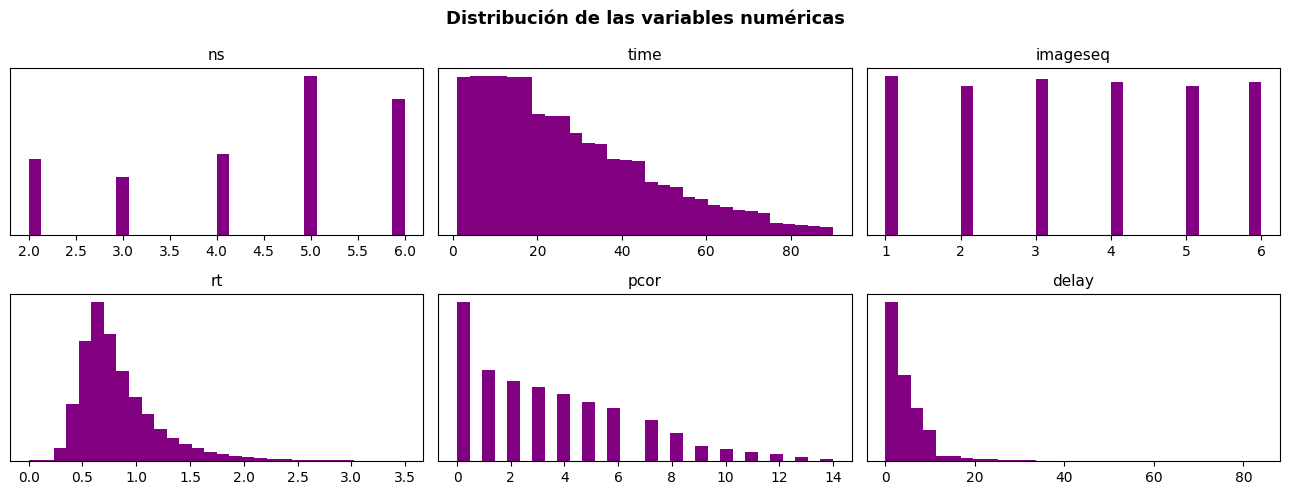

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(13, 5))

for ax, columna in zip(axes.ravel(), variables_numericas):
    ax.hist(df[columna].dropna(), bins=30, color='purple')
    ax.set_title(columna, fontsize=11)
    ax.set_yticks([])

fig.suptitle("Distribución de las variables numéricas",
             fontsize=13, color='black', fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura**: La gráfica 'ns', correspondiente al número de estímulos por conjunto (tamaño de conjunto) muestra una distribución correspondiente a sus valores predefinidos: 2,3,4,5 y 6. El 'time', que es el número de ensayo, disminuye su frecuencia conforme aumenta. Esto es consistente con que hay menor número de ensayos debido al tamaño del conjunto. La tarea experimental considera menos tamañaos de conjuntos altos. 'imageseq', la secuencia de la imagen, tiene los mismos valores predefinidos que 'ns', aunque una distribucón uniforme. El tiempo de reacción, 'rt', se sesga a la izquierda; lo que sugiere que los tiempos de reacción se distribuyen más en valores bajos. El número de ensayos correctos previos para un estímulo dado, 'pcor', también se sesga a la izquierda, pero es una variable discreta. Por último, 'delay', también se carga hacia la izquierda, entre 0-20. Esta gráfica sugiere que no pasa demasiado tiempo entre un estímulo y su acción correcta y volver a observar dicho estímulo.

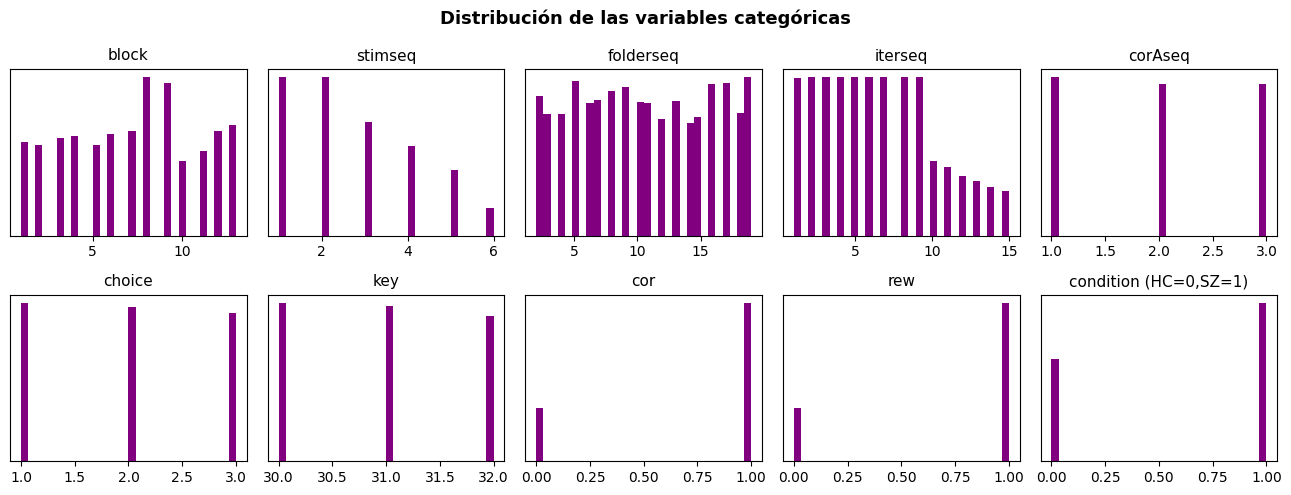

In [29]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5))

for ax, columna in zip(axes.ravel(), variables_categoricas):
    ax.hist(df[columna].dropna(), bins=30, color='purple')
    ax.set_title(columna, fontsize=11)
    ax.set_yticks([])

fig.suptitle("Distribución de las variables categóricas",
             fontsize=13, color='black', fontweight="bold")
plt.tight_layout()
plt.show()

**Lectura**: 'choice', 'key', y 'corAseq' solo tienen 3 valores discretos predefinidos, y esto se observa en sus gráficas. Por lo tanto, son consistentes con lo reportado en el artículo. 'cor', 'rew' y 'condition (HC=0,SZ=1)' son variables dicotomicas, y tambiés esto se visualiza en su distribución. 'cor' y 'rew' deben de tener la misma distribución, ya que si hubo una respuesta correcta se entrega una recompensa. 'block' corresponde al número del bloque, por lo que su distribucón es consistente con la cantidad de bloques por tarea experimental. 'stimseq' es solo un identificador. 'folderseq' es el número de la categoría de la imagen, 'iterseq' el número de iteración por estímulo por lo tanto, ambos identificadores.

**ANÁLISIS BIVARIADO**: relaciones entre pares de atributos, justificando cuáles se exploran y por qué

¿Cómo afecta el tamaño de conjunto en el delay?


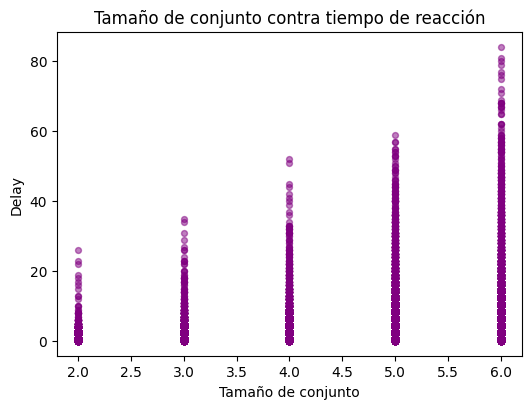

In [30]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(
    df["ns"],
    df["delay"],
    s=18,
    alpha=0.5,
    color='purple'
)
ax.set_xlabel("Tamaño de conjunto")
ax.set_ylabel("Delay")
ax.set_title("Tamaño de conjunto contra tiempo de reacción")
plt.show()

**Lectura**: Se observa mayor delay a mayor tamaño de conjunto. Que es consistente con el diseño experimental, ya que a mayor tamaño de estímulos tarda más en volver en aparecer el mismo estímulo.

¿Cómo afecta el tamaño de conjunto en la respuesta correcta?

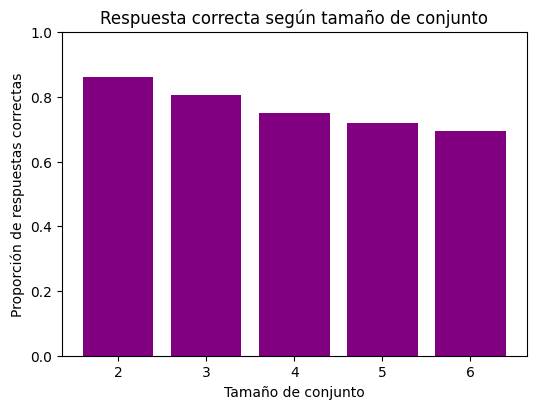

In [31]:
proporcion_correcta = df.groupby("ns")["cor"].mean()
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(
    proporcion_correcta.index,
    proporcion_correcta,
    color='purple'
)
ax.set_xlabel("Tamaño de conjunto")
ax.set_ylabel("Proporción de respuestas correctas")
ax.set_title("Respuesta correcta según tamaño de conjunto")
ax.set_ylim(0, 1)
plt.show()

**Lectura**: Se observa un leve patrón de menor proporción de respuestas correctas a mayor tamaño de conjunto. Que es consistente con el diseño experimental, ya que a mayor tamaño de estímulos se satura la memoria de trabajo.

¿Cómo afecta el grupo en la respuesta correcta?

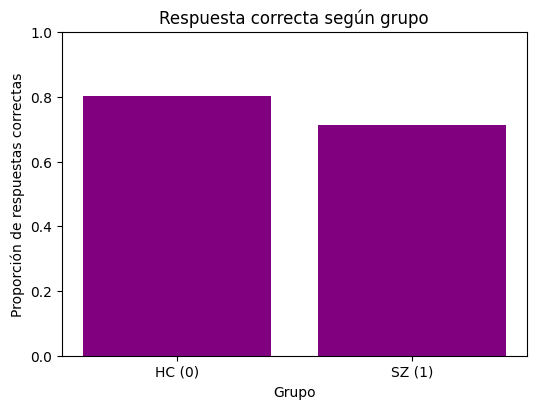

In [32]:
proporcion_correcta = df.groupby("condition (HC=0,SZ=1)")["cor"].mean()
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.bar(
    proporcion_correcta.index,
    proporcion_correcta,
    color='purple'
)
ax.set_xlabel("Grupo")
ax.set_ylabel("Proporción de respuestas correctas")
ax.set_title("Respuesta correcta según grupo")
ax.set_xticks([0, 1])
ax.set_xticklabels(["HC (0)", "SZ (1)"])
ax.set_ylim(0, 1)
plt.show()

**Lectura**: Se ve una pequeña disminución de respuestas correctas en el grupo 'esquizofrenia' en comparación al grupo control.

¿Cómo afecta el grupo en el delay?

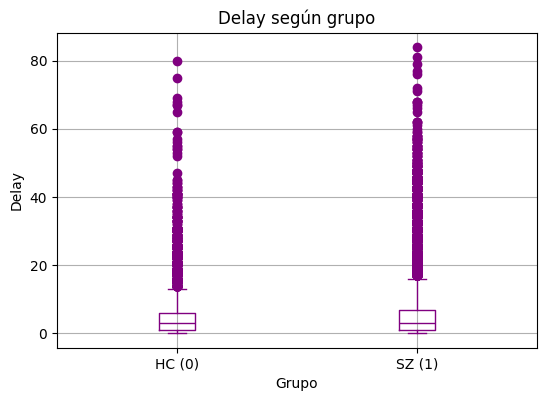

In [33]:
fig, ax = plt.subplots(figsize=(6, 4.2))
df.boxplot(
    column="delay",
    by="condition (HC=0,SZ=1)",
    ax=ax,
    boxprops=dict(color="purple"),
    medianprops=dict(color="purple"),
    whiskerprops=dict(color="purple"),
    capprops=dict(color="purple"),
    flierprops=dict(
        markeredgecolor="purple",
        markerfacecolor="purple")
)
ax.set_xlabel("Grupo")
ax.set_ylabel("Delay")
ax.set_title("Delay según grupo")
ax.set_xticks([1, 2])
ax.set_xticklabels(["HC (0)", "SZ (1)"])
plt.suptitle("")
plt.show()

**Lectura**: Se ve un leve aumento de delay en el grupo 'esquizofrenia' en comparación al grupo control. Sin embargo, ambos tienen una gran cantidad de datos atípicos. El bigote inferior se encuentra donde mismos, al igual que la media. Sin embargo el Q3 muestra mayor variabilidad en el grupo experimental que en el control.

**ANÁLISIS MULTIVARIADO**: Al menos una vista multivariada, e.g., matriz de correlación, matriz de dispersión, o el uso del color como tercera dimensión.

¿El delay de ve afectado por grupo y tamaño de conjunto?

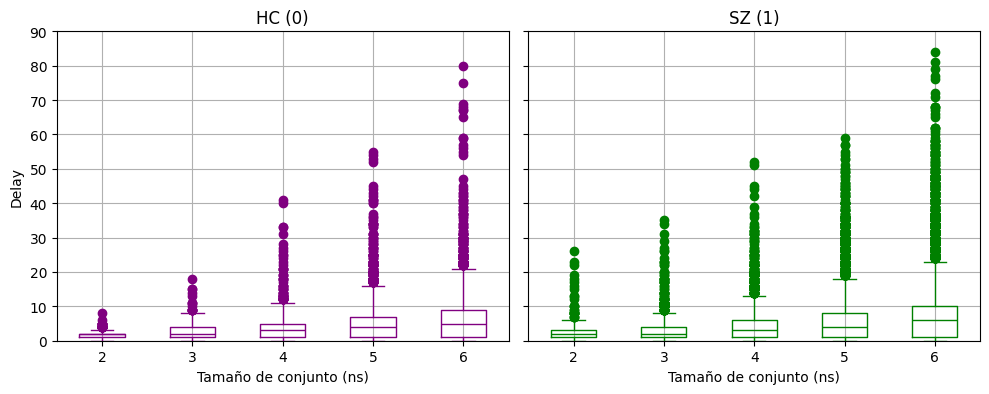

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
grupos = [0, 1]
nombres = ["HC (0)", "SZ (1)"]
colores = ["purple", "green"]
for ax, grupo, nombre, color in zip(axes, grupos, nombres, colores):
    datos = df[df["condition (HC=0,SZ=1)"] == grupo]
    datos.boxplot(
        column="delay",
        by="ns",
        ax=ax,
        boxprops=dict(color=color),
        medianprops=dict(color=color),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
        flierprops=dict(
            markeredgecolor=color,
            markerfacecolor=color
        )
    )
    ax.set_title(nombre)
    ax.set_xlabel("Tamaño de conjunto (ns)")
    ax.set_ylabel("Delay")
    # mismo rango eje y para las dos gráficas
    ax.set_ylim(0, 90)
# ocultar eje y de la segunda gráfica
axes[1].set_ylabel("")
axes[1].tick_params(axis="y", labelleft=False)
plt.suptitle("")
plt.tight_layout()
plt.show()

**Lectura**: Se observa mayor dispersión en el grupo experimental en comparación al control, independientemente del tamaño de conjunto, aunque mínima. A partir del tamaño de conjunto 3 se observa que el Q3 se expande más en el grupo 'esquizofrenia' que en el grupo control. Esto tiene sentido ya que el artículo concluye que la memoria de trabajo se ve afectada en la esquizofrenia, y a mayor cantidad de estímulos mayor saturación de la memoria de trabajo.

**Cierre con al menos tres hallazgos, las preguntas que abre el dataset, y los problemas que requerirían corrección antes de cualquier análisis posterior.**

HALLAZGOS
1. Los 181 datos registrados como '-1' son datos faltantes, no un valor posible de la variable. Por lo tanto, hay que decidir qué hacer con ellos. Con fines de la práctica los eliminé, pero para análisis complejos habría que considerar cómo tratarlos.
2. 'cor' y 'rew' tienen los mismos valores exactamente, por lo tanto, misma distribución. Para futuros análisis valdría la pena solo mantener una, ya que son la misma columna. Idéntica una a la otra, aportan la misma información.
3. Visualmente, se ve mayor efecto del tamaño de conjunto sobre el delay que el grupo experimental. Esto es interesante ya que las conclusiones del artículo sí atribuyen diferencias entre grupos, pero realizan análisis más complejos.

PREGUNTAS QUE ABRE EL DATASET
1. ¿Cuál columna determina el orden para estructurar los datos en series de tiempo?
2. Si el delay se ve mayormente afectado por el tamaño de conjunto, ¿cuáles son las variables que se ven afectadas por el grupo experimental?

PROBLEMAS QUE REQUIEREN CORRECCIÓN ANTES DE ANÁLISIS POSTERIORES
1. Establecer la columna que determina cómo organizar los datos para que se estructuren como series de tiempo
2. Analizar que los 181 datos eliminados no generen huecos en las líneas de tiempo.
3. Eliminar una columna entre 'cor' y 'rew'.

**Declaración de uso de IA generativa**

Este notebook fue elaborado con apoyo de ChatGPT (OpenAI) para resolver dudas sobre Python, análisis de datos y visualización. La interpretación de los resultados y la revisión final son responsabilidad del autor.